# BAN-8101 Predictive Analytics
## Week 3 · Data Preparation & Linear Regression

Data source: https://www.kaggle.com/datasets/camnugent/california-housing-prices

**The question:** How well can housing characteristics predict a continuous housing value, and does adding predictors improve predictions on unseen observations?

We will fit **Model 1: simple linear regression** using one predictor and **Model 2: multiple linear regression** using all available predictors. Both models use the same training and test observations.


### Learning goals and meeting plan

By the end, you should be able to define X and y; inspect data; handle missing values and categories without leaking test information; fit and interpret two regression models; and compare predictions using metrics and diagnostic plots.

**Workflow:** Problem → Load → Inspect → Define X/y → Split → Fit preparation on training data → Train → Predict → Evaluate → Communicate.

In the driving simulation, an agent uses observations to act. Here we practice predicting a number from tabular observations. Later, predicting a continuous steering angle will reuse this workflow with different inputs and models.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 20260914 # control the randomness in this Notebook
plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 15)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)

Python: 3.11.9
scikit-learn: 1.6.1


### 2. Load the supplied California Housing CSV

**Data source:** `CA_housing.csv`, supplied by the instructor and described as obtained from Kaggle. This version contains California census block-group housing data, including location, aggregate counts, median income, median house value, and ocean proximity. One row represents a **census block group**, not an individual home sale.

This CSV differs from the processed scikit-learn version: it includes total room and bedroom counts, households, a categorical `ocean_proximity` column, and missing bedroom values. Its target, `median_house_value`, is already in **US dollars**; do not multiply it by 100,000. `median_income` is expressed in units of approximately $10,000.

Our question is: **How well can available block-group characteristics predict median house value?** Model 1 uses median income alone. Model 2 uses all nine predictor columns. We treat the total counts as counts rather than silently converting them to household averages.

In [2]:
# Paths are relative to Jupyter's working folder unless you supply an absolute path.

# define the path to the dataset
DATA_PATH = Path("../../data/CA_housing.csv")
if not DATA_PATH.is_file():
    alternative = Path("data") / "CA_housing.csv"
    if alternative.is_file():
        DATA_PATH = alternative
    else:
        raise FileNotFoundError(
            "Place CA_housing.csv beside the notebook (or in data/), "
            "or set DATA_PATH to your CSV location. "
            f"Current working folder: {Path.cwd()}")
# read the datset to Python environment
raw_df = pd.read_csv(DATA_PATH)
# target value we will focus
target = "median_house_value"
# main features
simple_feature = "median_income"
dollar_multiplier = 1  # CSV target is already dollars; used consistently in metric/plot cells.
dataset_name = "California Housing Dataset"
row_unit = "census block group"
feature_units = {
    "longitude": "longitude (degrees)",
    "latitude": "latitude (degrees)",
    "housing_median_age": "median house age (years)",
    "total_rooms": "total rooms in block group (count)",
    "total_bedrooms": "total bedrooms in block group (count)",
    "population": "block-group population (people)",
    "households": "block-group households (count)",
    "median_income": "median income ($10,000 units)",
    "ocean_proximity": "ocean proximity (category)"
}
target_description = "Median block-group house value (US dollars)"
expected_columns = list(feature_units) + [target]
if set(raw_df.columns) != set(expected_columns):
    raise ValueError(f"Unexpected CSV columns. Expected: {expected_columns}")

print("DATA SOURCE:", dataset_name)
print("Loaded file:", DATA_PATH.name)
print("One row:", row_unit)
print("Shape:", raw_df.shape, "| Target:", target)
display(raw_df.head())

DATA SOURCE: California Housing Dataset
Loaded file: CA_housing.csv
One row: census block group
Shape: (20640, 10) | Target: median_house_value


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,"452,600.000",NEAR BAY
1,-122.220,37.860,21.000,"7,099.000","1,106.000","2,401.000","1,138.000",8.301,"358,500.000",NEAR BAY
2,-122.240,37.850,52.000,"1,467.000",190.000,496.000,177.000,7.257,"352,100.000",NEAR BAY
3,-122.250,37.850,52.000,"1,274.000",235.000,558.000,219.000,5.643,"341,300.000",NEAR BAY
4,-122.250,37.850,52.000,"1,627.000",280.000,565.000,259.000,3.846,"342,200.000",NEAR BAY


In [3]:
dictionary = pd.DataFrame([
    {"Column": col, "Role": "Predictor", "Meaning / unit": unit}
    for col, unit in feature_units.items()
] + [{"Column": target, "Role": "Target", "Meaning / unit": target_description}])
display(dictionary)
display(Markdown(
    "These are historical, area-level housing observations, not current individual sale prices. "
    "The supplied target reaches a ceiling of $500,001, which may create a visible edge "
    "in plots and complicate prediction of higher values. Location categories may also "
    "have very different sample sizes; inspect their counts below."))

,Column,Role,Meaning / unit
0,longitude,Predictor,longitude (degrees)
1,latitude,Predictor,latitude (degrees)
2,housing_median_age,Predictor,median house age (years)
3,total_rooms,Predictor,total rooms in block group (count)
4,total_bedrooms,Predictor,total bedrooms in block group (count)
5,population,Predictor,block-group population (people)
6,households,Predictor,block-group households (count)
7,median_income,Predictor,"median income ($10,000 units)"
8,ocean_proximity,Predictor,ocean proximity (category)
9,median_house_value,Target,Median block-group house value (US dollars)


These are historical, area-level housing observations, not current individual sale prices. The supplied target reaches a ceiling of $500,001, which may create a visible edge in plots and complicate prediction of higher values. Location categories may also have very different sample sizes; inspect their counts below.

### 3. Inspect the raw table

Before modeling, confirm the unit of observation, column meanings, types, ranges, missing entries, and repeated records. An integer can represent a quantity or a category; its meaning determines treatment. `total_bedrooms` is a count, whereas `ocean_proximity` is a nominal category.

This first inspection checks structure and data quality. We will inspect predictor–target relationships **only in the training data**. We do not choose predictors by checking which one predicts the test outcomes best.

In [4]:
raw_df.info()
display(raw_df.describe(include="all").T)
display(raw_df.isna().sum().rename("Missing entries").to_frame())
print("Exact duplicate rows:", raw_df.duplicated().sum())
print("Unique row indexes:", raw_df.index.is_unique)
display(raw_df["ocean_proximity"].value_counts(dropna=False).rename("Rows per category").to_frame())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,"20,640.000",NaN,NaN,NaN,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,"20,640.000",NaN,NaN,NaN,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,"20,640.000",NaN,NaN,NaN,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,"20,640.000",NaN,NaN,NaN,"2,635.763","2,181.615",2.000,"1,447.750","2,127.000","3,148.000","39,320.000"
total_bedrooms,"20,433.000",NaN,NaN,NaN,537.871,421.385,1.000,296.000,435.000,647.000,"6,445.000"
population,"20,640.000",NaN,NaN,NaN,"1,425.477","1,132.462",3.000,787.000,"1,166.000","1,725.000","35,682.000"
households,"20,640.000",NaN,NaN,NaN,499.540,382.330,1.000,280.000,409.000,605.000,"6,082.000"
median_income,"20,640.000",NaN,NaN,NaN,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,"20,640.000",NaN,NaN,NaN,"206,855.817","115,395.616","14,999.000","119,600.000","179,700.000","264,725.000","500,001.000"
ocean_proximity,20640,5,<1H OCEAN,9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Missing entries
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


Exact duplicate rows: 0
Unique row indexes: True


,Rows per category
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


**Pause and discuss**

1. What is one row in this dataset? What exactly are we predicting?
2. Is this a regression or classification problem, and why?
3. Why would the units of income and house value matter when interpreting a coefficient?

**Your notes:** _Type here._

### 4. Prepare the real data-quality issues

The supplied CSV has **207 missing `total_bedrooms` values**, no missing targets, and no exact duplicate rows. We retain those observations and will replace missing bedroom counts using a median learned from the training set. No synthetic missing values or duplicate records are added.

Preserve `raw_df` and work on a copy named `df`. Check numeric types, infinite values, missing labels, and duplicate records before proceeding. In a different dataset, investigate missing targets rather than inventing labels. Identical rows can describe distinct observations; investigate provenance before deleting them. This supplied file needs no row deletion.

In [5]:
df = raw_df.copy()
numeric_candidates = list(feature_units.keys())[:-1]
for col in numeric_candidates + [target]:
    df[col] = pd.to_numeric(df[col], errors="raise")

print("Exact duplicate rows (none removed):", int(df.duplicated().sum()))
display(df.isna().sum().rename("Missing entries in supplied CSV").to_frame())
assert df[target].notna().all(), "Investigate missing targets; do not impute labels."
assert not np.isinf(df.select_dtypes(include="number").to_numpy()).any()
assert df.index.is_unique
print("Rows retained:", len(df))

Exact duplicate rows (none removed): 0


,Missing entries in supplied CSV
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


Rows retained: 20640


### 5. Define X and y, then split once

`X` is a two-dimensional table of predictors. `y` is the one-dimensional target. We exclude the target from X because it would not be known when making a new prediction. Row indexes help check that outcomes stay aligned with predictors; we do not use them as predictors.

An 80/20 split reserves 20% of observations for evaluation. Both models use these **same rows**. The random seed makes the split repeatable, not inherently better.

We assume randomly sampled observations are suitable for this introductory comparison. Predicting future sales would call for a time split; testing transfer to new regions would call for a geographic/group split. Nearby California block groups may be related, so a random split can overstate geographic generalization.

In [6]:
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED)

numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()
simple_features = [simple_feature]  # A list preserves the 2-D shape required by sklearn.
assert target not in X.columns
assert set(X_train.index).isdisjoint(X_test.index)
assert X_train.index.equals(y_train.index) and X_test.index.equals(y_test.index)
display(pd.DataFrame({"Split": ["Train", "Test"],
                      "Rows": [len(X_train), len(X_test)],
                      "Raw predictors": [X_train.shape[1], X_test.shape[1]]}))
print("Simple model predictor:", simple_feature)
print("Multiple model numeric predictors:", numeric_features)
print("Multiple model categorical predictors:", categorical_features)

,Split,Rows,Raw predictors
0,Train,16512,9
1,Test,4128,9


Simple model predictor: median_income
Multiple model numeric predictors: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Multiple model categorical predictors: ['ocean_proximity']


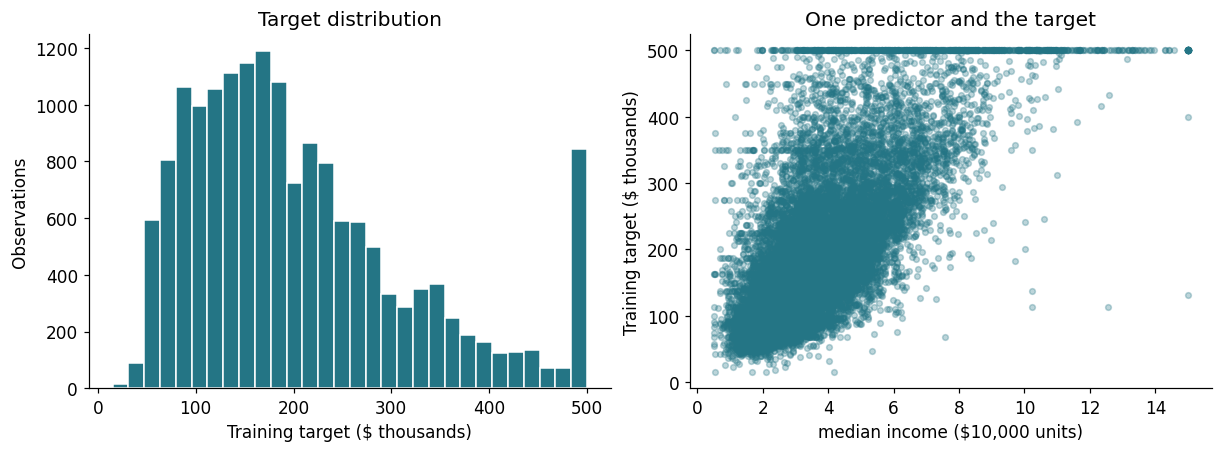

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
longitude,1.000,-0.930,-0.110,0.050,0.070,0.100,0.060,-0.020
latitude,-0.930,1.000,0.010,-0.040,-0.070,-0.110,-0.070,-0.070
housing_median_age,-0.110,0.010,1.000,-0.360,-0.320,-0.300,-0.300,-0.110
total_rooms,0.050,-0.040,-0.360,1.000,0.930,0.860,0.920,0.190
total_bedrooms,0.070,-0.070,-0.320,0.930,1.000,0.880,0.980,-0.010
population,0.100,-0.110,-0.300,0.860,0.880,1.000,0.910,-0.000
households,0.060,-0.070,-0.300,0.920,0.980,0.910,1.000,0.010
median_income,-0.020,-0.070,-0.110,0.190,-0.010,-0.000,0.010,1.000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].hist(y_train * dollar_multiplier / 1000, bins=30, color="#247585", edgecolor="white")
axes[0].set(xlabel="Training target ($ thousands)", ylabel="Observations", title="Target distribution")
axes[1].scatter(X_train[simple_feature], y_train * dollar_multiplier / 1000,
                s=14, alpha=0.3, color="#247585")
axes[1].set(xlabel=feature_units[simple_feature], ylabel="Training target ($ thousands)",
            title="One predictor and the target")
plt.show()
display(X_train[numeric_features].corr().round(2))

**Reflection:** Does the training scatterplot suggest a straight-line trend? Is there changing spread or an apparent target ceiling? Which predictors are correlated with one another? We chose median income for its domain meaning before examining test results.

**Your notes:** _Type here._

### 6. Missing values, categories, and leakage

Use the **training median** for missing numeric values. A pipeline learns medians during `.fit(X_train, y_train)` and reuses them during `.predict(X_test)`. Learning a median from the whole dataset, or recalculating it on the test set, would break this separation. Median income has no missing values here, but bedroom counts do; the same preparation pattern works for both models.

For `ocean_proximity`, we include a **most-frequent training category** imputer for completeness, although this file has no missing categories. Then we one-hot encode. With an intercept, dropping one category gives a reference group and avoids redundant dummy columns. A dummy coefficient compares that category with the reference group, holding other predictors fixed. Arbitrary codes such as INLAND=1 and NEAR BAY=2 would impose unjustified ordering and spacing. The fitted encoder prints the actual reference group below.

We retain original numeric units for interpretation. Scaling is not required for this ordinary least-squares lesson; regularization and distance-based models make scaling more consequential. Any learned scaling must also be fit on training data only.

### 7. Model 1 — Simple linear regression

$$y_i = \beta_0 + \beta_1 x_i + \epsilon_i,\qquad
\hat y_i = \hat\beta_0 + \hat\beta_1 x_i.$$

The intercept is the predicted target when the predictor equals zero. The slope is the change in predicted target for a one-unit increase in the predictor. The error term represents what the line does not explain. Ordinary least squares chooses coefficients to minimize the sum of squared **training** residuals.

The pipeline has two steps: replace missing predictor values, then fit the regression line. Do not fill missing values manually using the whole dataset first.

In [8]:
# simpleimputer will insert those missing values to the dataset 
# using median value of the predictor which is 3.54035 x 10,000

model1 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), # not necessary because we are building a SLR. 
    ("regression", LinearRegression())
])
model1.fit(X_train[simple_features], y_train)
reg1 = model1.named_steps["regression"]
print(f"Fitted equation: {target} = {reg1.intercept_:.4f} + ({reg1.coef_[0]:.4f}) * {simple_feature}")
print(f"Slope in dollars per predictor unit: ${reg1.coef_[0] * dollar_multiplier:,.2f}")
print("Training median used for missing predictor values:", model1.named_steps["imputer"].statistics_[0])

Fitted equation: median_house_value = 45437.4092 + (41611.4352) * median_income
Slope in dollars per predictor unit: $41,611.44
Training median used for missing predictor values: 3.54035


**Interpret the printed equation.** One unit of `median_income` represents approximately \$10,000 of block-group median income. One unit of `median_house_value` is already **one dollar**. The printed slope is therefore the predicted dollar difference in median house value for a \$10,000 difference in median income.

The coefficient describes an association in this fitted model. It does not show that increasing income will cause that house-value change. Zero income falls outside the observed range, so the intercept may lack a useful practical interpretation.

**Your interpretation of the slope and intercept:** _Type here._

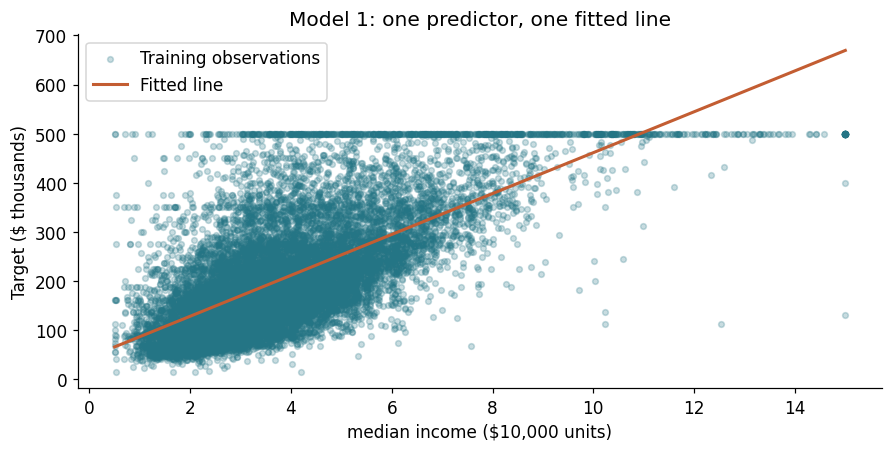

In [9]:
grid = pd.DataFrame({simple_feature: np.linspace(
    X_train[simple_feature].min(), X_train[simple_feature].max(), 150)})
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.scatter(X_train[simple_feature], y_train * dollar_multiplier / 1000,
           s=14, alpha=0.25, color="#247585", label="Training observations")
ax.plot(grid[simple_feature], model1.predict(grid) * dollar_multiplier / 1000,
        color="#c35d32", linewidth=2, label="Fitted line")
ax.set(xlabel=feature_units[simple_feature], ylabel="Target ($ thousands)",
       title="Model 1: one predictor, one fitted line")
ax.legend()
plt.show()

### 8. Model 2 — Multiple linear regression

$$\hat y_i = \hat\beta_0 + \hat\beta_1x_{i1} + \cdots + \hat\beta_px_{ip}.$$

We now use all available predictors. Each numeric coefficient is the predicted change for a one-unit increase in that feature **holding the other model inputs fixed**. Category indicators count as additional model inputs after encoding.

`ColumnTransformer` sends numeric and categorical columns through the appropriate preparation steps. The surrounding pipeline fits preparation and regression together using training data only. `.predict()` later repeats the fitted preparation automatically.

In [10]:
transformers = [("numeric", SimpleImputer(strategy="median"), numeric_features)]
if categorical_features:
    category_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
    ])
    transformers.append(("categorical", category_pipeline, categorical_features))

preprocessor = ColumnTransformer(transformers, remainder="drop", verbose_feature_names_out=False)
model2 = Pipeline([("prepare", preprocessor), ("regression", LinearRegression())])
model2.fit(X_train, y_train)

fitted_preprocessor = model2.named_steps["prepare"]
feature_names = fitted_preprocessor.get_feature_names_out()
reg2 = model2.named_steps["regression"]
print("Raw predictors:", X_train.shape[1], "| Encoded inputs:", len(feature_names))
display(pd.DataFrame({"Numeric predictor": numeric_features,
    "Training median": fitted_preprocessor.named_transformers_["numeric"].statistics_}))
if categorical_features:
    encoder = fitted_preprocessor.named_transformers_["categorical"].named_steps["encoder"]
    for col, categories, drop_idx in zip(categorical_features, encoder.categories_, encoder.drop_idx_):
        print(col, "categories:", list(categories), "| reference:", categories[drop_idx])
else:
    print("All predictors are numeric; no categorical encoding was needed.")

Raw predictors: 9 | Encoded inputs: 12


,Numeric predictor,Training median
0,longitude,-118.490
1,latitude,34.260
2,housing_median_age,29.000
3,total_rooms,"2,121.000"
4,total_bedrooms,434.000
5,population,"1,164.000"
6,households,409.000
7,median_income,3.540


ocean_proximity categories: ['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'] | reference: <1H OCEAN


An unseen category is encoded as all zeros under `handle_unknown="ignore"` (with a warning), so it is treated like the reference group here. That keeps prediction running but does not teach the model about a new location. Production use needs an explicit unknown-category policy and monitoring.

### 9. Interpret coefficients carefully

The table below keeps both native target units and dollar equivalents. A numeric coefficient is per one original predictor unit; a category coefficient is the difference from the printed reference category. Coefficient magnitudes across differently scaled features are **not** a feature-importance ranking.

In [11]:
coefficients = pd.DataFrame({"Feature": feature_names, "Coefficient (target units)": reg2.coef_,
    "Coefficient (USD)": reg2.coef_ * dollar_multiplier})
display(coefficients)
print(f"Model 2 intercept: {reg2.intercept_:,.4f} target units")
slope2 = coefficients.set_index("Feature").loc[simple_feature, "Coefficient (USD)"]
display(pd.DataFrame({"Model": ["Simple", "Multiple"],
    "Predictor": [simple_feature, simple_feature],
    "Slope (USD per unit)": [reg1.coef_[0] * dollar_multiplier, slope2]}))

,Feature,Coefficient (target units),Coefficient (USD)
0,longitude,"-27,056.631","-27,056.631"
1,latitude,"-25,781.662","-25,781.662"
2,housing_median_age,"1,063.855","1,063.855"
3,total_rooms,-4.600,-4.600
4,total_bedrooms,67.955,67.955
5,population,-37.502,-37.502
6,households,76.693,76.693
7,median_income,"38,532.136","38,532.136"
8,ocean_proximity_INLAND,"-39,158.526","-39,158.526"
9,ocean_proximity_ISLAND,"162,059.127","162,059.127"


Model 2 intercept: -2,286,893.2570 target units


,Model,Predictor,Slope (USD per unit)
0,Simple,median_income,"41,611.435"
1,Multiple,median_income,"38,532.136"


The simple slope summarizes an unadjusted association. The multiple-model slope adjusts for the other included predictors, so its magnitude or sign can change. Correlated predictors can make individual coefficients unstable even when predictions are useful. Holding features fixed can also describe unrealistic combinations (for example, many more rooms with the same population and household count).

**Reflection:** Interpret one numeric coefficient using its units and “holding other predictors fixed.” If categories are present, interpret one category coefficient relative to its reference. Why might the simple and multiple slopes differ? Why does neither demonstrate causality?

**Your notes:** _Type here._

### 10. Generate predictions on unseen rows

We call `predict`, never `fit`, on the test set. Outputs are point predictions, not uncertainty intervals. The pipelines also accept new observations with the same predictor columns, units, and meanings; the target is not required.

The table uses dollars consistently for both models. Positive residuals mean we **underpredicted**; negative residuals mean we **overpredicted**.

In [12]:
pred1 = model1.predict(X_test[simple_features])
pred2 = model2.predict(X_test)
actual_usd = y_test * dollar_multiplier
prediction_table = pd.DataFrame({"Actual_USD": actual_usd,
    "Simple_USD": pred1 * dollar_multiplier, "Multiple_USD": pred2 * dollar_multiplier},
    index=y_test.index)
prediction_table["Simple_residual_USD"] = prediction_table.Actual_USD - prediction_table.Simple_USD
prediction_table["Multiple_residual_USD"] = prediction_table.Actual_USD - prediction_table.Multiple_USD
display(prediction_table.head(10).round(2))

# Work through the multiple-model prediction for one unseen row.
new_observation = X_test.iloc[[0]].copy()
display(new_observation)
prepared_row = fitted_preprocessor.transform(new_observation)[0]
manual_prediction = reg2.intercept_ + np.dot(prepared_row, reg2.coef_)
print(f"Intercept + sum of coefficient × prepared input = ${manual_prediction * dollar_multiplier:,.2f}")
print(f"Pipeline prediction = ${model2.predict(new_observation)[0] * dollar_multiplier:,.2f}")
assert np.isclose(manual_prediction, pred2[0])

,Actual_USD,Simple_USD,Multiple_USD,Simple_residual_USD,Multiple_residual_USD
7867,"243,800.000","154,392.790","193,457.900","89,407.210","50,342.100"
3861,"328,500.000","216,951.420","259,210.100","111,548.580","69,289.900"
1774,"140,300.000","159,415.290","214,050.720","-19,115.290","-73,750.720"
17148,"500,001.000","352,034.620","393,062.770","147,966.380","106,938.230"
13819,"104,100.000","187,677.780","132,296.590","-83,577.780","-28,196.590"
10787,"268,800.000","175,702.010","215,368.210","93,097.990","53,431.790"
1716,"173,500.000","223,750.730","255,975.440","-50,250.730","-82,475.440"
3788,"184,400.000","145,750.100","181,015.610","38,649.900","3,384.390"
5394,"185,700.000","155,299.920","191,760.060","30,400.080","-6,060.060"
18333,"402,500.000","134,510.850","207,968.140","267,989.150","194,531.860"


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
7867,-118.120,33.880,25.000,"1,768.000",559.000,983.000,488.000,2.618,<1H OCEAN


Intercept + sum of coefficient × prepared input = $193,457.90
Pipeline prediction = $193,457.90


### 11. Evaluate both models

For residual $e_i=y_i-\hat y_i$ over $n$ evaluation observations:

| Metric | Formula | Meaning and preferred direction |
|---|---|---|
| MAE | $\frac{1}{n}\sum_i \lvert e_i\rvert$ | Average absolute error; lower is better; dollars here |
| MSE | $\frac{1}{n}\sum_i e_i^2$ | Penalizes large errors strongly; lower is better; dollars squared |
| RMSE | $\sqrt{\mathrm{MSE}}$ | Squared-error measure returned to dollars; lower is better |
| $R^2$ | $1-\frac{\sum_i e_i^2}{\sum_i(y_i-\bar y)^2}$ | Improvement over predicting the evaluation-set mean in squared-error terms; higher is better |

$R^2=1$ is perfect; $R^2=0$ matches the evaluation-mean reference; $R^2<0$ is worse than that reference. It is **not percent accuracy**. On test data, $\bar y$ in this formula is the test mean, not the training mean. A deployable naive benchmark instead predicts the **training target mean**, which we include separately.

Compare errors in the same units on the same observations. Training performance describes fit; test performance estimates generalization under this split. A large training-to-test gap suggests overfitting or a distribution difference. RMSE is at least MAE, and a large gap often indicates a few especially large errors.

In [13]:
def regression_metrics(y_true, predictions):
    # Convert once, here, so every reported error has explicit dollar units.
    truth = np.asarray(y_true) * dollar_multiplier
    estimate = np.asarray(predictions) * dollar_multiplier
    mse = mean_squared_error(truth, estimate)
    return {"MAE ($)": mean_absolute_error(truth, estimate),
            "MSE ($ squared)": mse, "RMSE ($)": np.sqrt(mse),
            "R2": r2_score(truth, estimate)}

rows = []
for name, model, columns in [("Model 1: Simple", model1, simple_features),
                              ("Model 2: Multiple", model2, X.columns.tolist())]:
    for split, features, truth in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        rows.append({"Model": name, "Split": split,
                     **regression_metrics(truth, model.predict(features[columns]))})
scores = pd.DataFrame(rows).set_index(["Model", "Split"])
display(scores.round(3))

test_comparison = scores.xs("Test", level="Split").copy()
baseline_pred = np.full(len(y_test), y_train.mean())
test_comparison.loc["Training-mean benchmark"] = pd.Series(regression_metrics(y_test, baseline_pred))
test_comparison["Encoded inputs"] = [1, len(feature_names), 0]
display(test_comparison.round(3))

MAE ($)   MSE ($ squared)   RMSE ($)    R2
Model             Split                                              
Model 1: Simple   Train 62,491.928 6,970,952,929.726 83,492.233 0.476
                  Test  62,940.935 7,173,973,667.112 84,699.313 0.464
Model 2: Multiple Train 49,752.529 4,697,371,932.974 68,537.376 0.647
                  Test  50,008.129 4,822,943,134.799 69,447.413 0.639

,MAE ($),MSE ($ squared),RMSE ($),R2,Encoded inputs
Model,,,,,
Model 1: Simple,"62,940.935","7,173,973,667.112","84,699.313",0.464,1
Model 2: Multiple,"50,008.129","4,822,943,134.799","69,447.413",0.639,12
Training-mean benchmark,"91,311.861","13,373,577,802.363","115,644.186",-0.000,0


### 12. Actual versus predicted values

A perfect model places every point on the dashed 45-degree line. Above that line means overprediction; below it means underprediction. Both panels use the same axis limits, so visual comparisons are fair. Axis values are **thousands of dollars**.

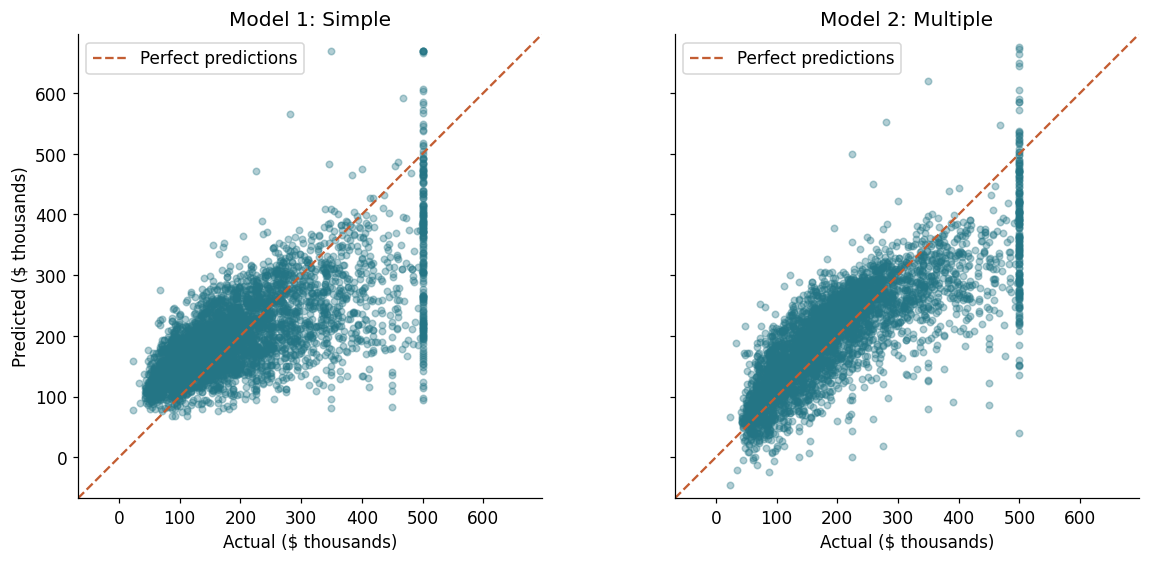

In [14]:
all_values = np.concatenate([actual_usd.to_numpy(), pred1 * dollar_multiplier, pred2 * dollar_multiplier]) / 1000
low, high = all_values.min(), all_values.max()
pad = 0.03 * (high - low)
limits = (low - pad, high + pad)
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True, constrained_layout=True)
for ax, prediction, title in zip(axes, [pred1, pred2], ["Model 1: Simple", "Model 2: Multiple"]):
    ax.scatter(actual_usd / 1000, prediction * dollar_multiplier / 1000,
               s=18, alpha=0.35, color="#247585")
    ax.plot(limits, limits, "--", color="#c35d32", label="Perfect predictions")
    ax.set(xlim=limits, ylim=limits, xlabel="Actual ($ thousands)", title=title)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper left")
axes[0].set_ylabel("Predicted ($ thousands)")
plt.show()

### 13. Residual plots and error analysis

Plot residuals against fitted predictions. A patternless cloud around zero with roughly constant spread supports a useful linear approximation. Curvature suggests a missing nonlinear relationship; a widening funnel suggests changing error variance; isolated points merit investigation. A plot alone does not prove the model assumptions hold.

Residual plots use the same sign convention as our table: **actual − predicted**. In contrast to the previous plots, points above zero here represent underprediction. We keep common limits for the two models.

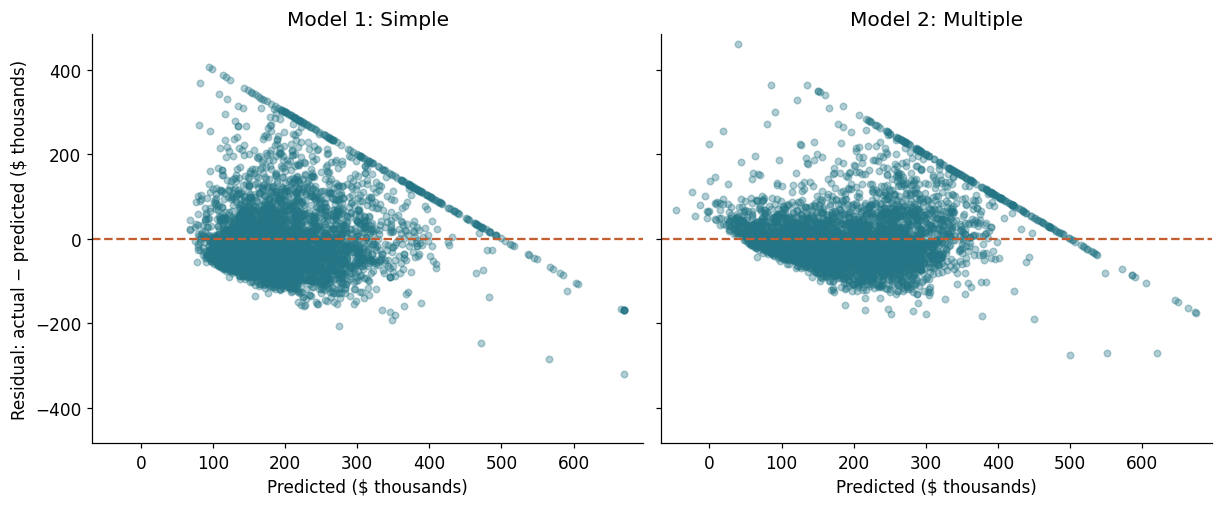

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,Actual_USD,Simple_USD,Multiple_USD,Simple_residual_USD,Multiple_residual_USD
1914,-120.100,38.910,33.000,"1,561.000",282.000,30.000,11.000,1.880,INLAND,"500,001.000","123,458.850","39,340.920","376,542.150","460,660.080"
6639,-118.150,34.150,52.000,275.000,123.000,273.000,111.000,1.170,<1H OCEAN,"500,001.000","93,985.470","135,048.260","406,015.530","364,952.740"
19542,-120.920,37.630,39.000,45.000,8.000,22.000,9.000,1.770,INLAND,"450,000.000","119,002.270","85,285.280","330,997.730","364,714.720"
9850,-121.890,36.600,19.000,656.000,200.000,248.000,173.000,1.270,<1H OCEAN,"500,000.000","98,100.840","150,950.920","401,899.160","349,049.080"
12069,-117.550,33.830,6.000,502.000,76.000,228.000,65.000,4.240,INLAND,"500,001.000","221,811.640","151,256.960","278,189.360","348,744.040"


Negative predicted housing values: 9


In [15]:
residual1 = (y_test.to_numpy() - pred1) * dollar_multiplier / 1000
residual2 = (y_test.to_numpy() - pred2) * dollar_multiplier / 1000
max_residual = max(np.abs(residual1).max(), np.abs(residual2).max()) * 1.05
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True, constrained_layout=True)
for ax, prediction, residual, title in zip(axes, [pred1, pred2], [residual1, residual2],
                                          ["Model 1: Simple", "Model 2: Multiple"]):
    ax.scatter(prediction * dollar_multiplier / 1000, residual, s=18, alpha=0.35, color="#247585")
    ax.axhline(0, linestyle="--", color="#c35d32")
    ax.set(xlabel="Predicted ($ thousands)", title=title, xlim=limits,
           ylim=(-max_residual, max_residual))
axes[0].set_ylabel("Residual: actual − predicted ($ thousands)")
plt.show()

worst_indices = prediction_table.Multiple_residual_USD.abs().nlargest(5).index
display(X_test.loc[worst_indices].join(prediction_table.loc[worst_indices]).round(2))
print("Negative predicted housing values:", int((pred2 < 0).sum()))

Inspect large errors for unusual inputs, imputation, target limits, and plausible data-quality problems. Do not delete valid difficult cases merely to improve metrics. Ordinary linear regression can produce negative values or values beyond an observed cap; we report raw predictions rather than silently clipping them.

California Housing may show effects of its target ceiling and spatial structure. The CSV also contains just five ISLAND observations, so that category's coefficient is based on very limited evidence. Normality is not needed to calculate point predictions or these metrics; formal confidence intervals and hypothesis tests require additional assumptions and analysis beyond this lab.

**Your diagnosis:** Identify a visible pattern or lack of pattern in each plot, cite one large-error observation, and propose one explanation to investigate. _Type here._

### 14. Compare models and communicate a decision

For this exercise, use **test MAE as the primary criterion**, chosen in advance because dollar errors are easy to explain. Use RMSE, R², the benchmark, and residual patterns as supporting evidence. More predictors do not guarantee better unseen-data predictions. Any improvement must also justify extra data collection and complexity.

This is a comparison of two prespecified models, not an invitation to repeatedly tune against the test set. In Week 5, cross-validation and regularization will support model selection within training data. A final untouched holdout is needed after iterative selection.

Dataset: California Housing Dataset
Lower test MAE: Model 2: Multiple
MAE reduction from simple to multiple: $12,932.81 (20.5%)
A negative reduction means the multiple model did worse.


,MAE ($),MSE ($ squared),RMSE ($),R2,Encoded inputs
Model,,,,,
Model 1: Simple,"62,940.935","7,173,973,667.112","84,699.313",0.464,1
Model 2: Multiple,"50,008.129","4,822,943,134.799","69,447.413",0.639,12
Training-mean benchmark,"91,311.861","13,373,577,802.363","115,644.186",-0.000,0


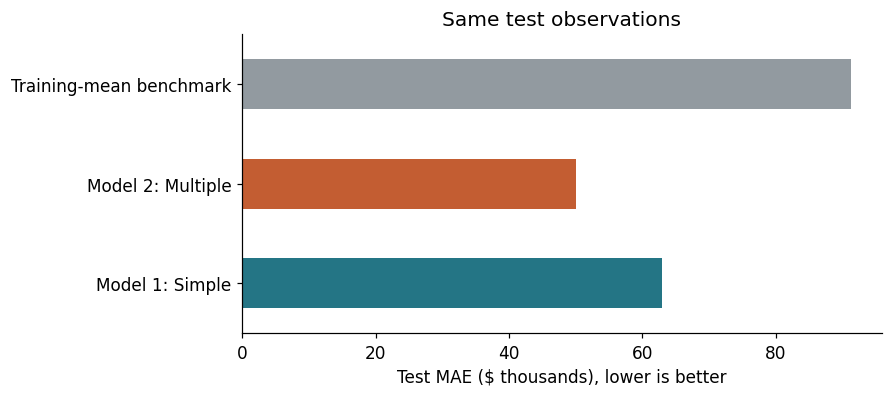

In [16]:
simple_mae = test_comparison.loc["Model 1: Simple", "MAE ($)"]
multiple_mae = test_comparison.loc["Model 2: Multiple", "MAE ($)"]
change = simple_mae - multiple_mae
percent_change = 100 * change / simple_mae
preferred = "Model 2: Multiple" if multiple_mae < simple_mae else (
    "Model 1: Simple" if simple_mae < multiple_mae else "Tie")
print("Dataset:", dataset_name)
print(f"Lower test MAE: {preferred}")
print(f"MAE reduction from simple to multiple: ${change:,.2f} ({percent_change:.1f}%)") # Do our regression models predict better than simply guessing the average?
print("A negative reduction means the multiple model did worse.")
display(test_comparison.round(3))

fig, ax = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
test_comparison["MAE ($)"].div(1000).plot.barh(ax=ax, color=["#247585", "#c35d32", "#929aa0"])
ax.set(xlabel="Test MAE ($ thousands), lower is better", ylabel="", title="Same test observations")
plt.show()

### How well the missing data imputation is?

,Observed,After imputation
count,"16,342.000","16,512.000"
mean,537.622,536.555
std,422.773,420.721
min,1.000,1.000
25%,295.000,297.000
50%,434.000,434.000
75%,646.000,643.000
max,"6,445.000","6,445.000"


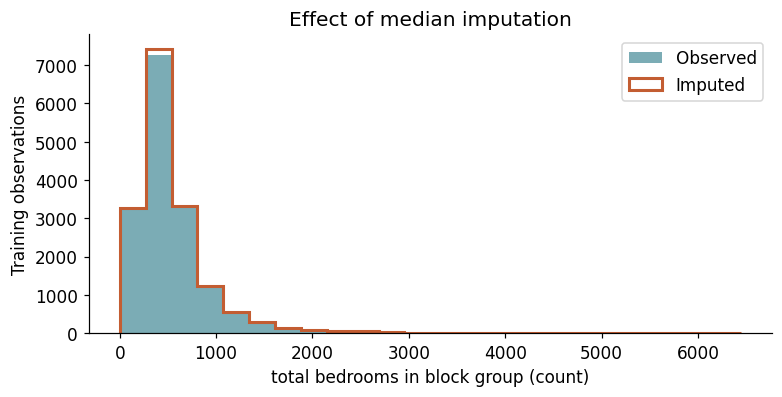

In [17]:
# Student workspace: change lab_feature to another numeric predictor with missing values.
lab_feature = "total_bedrooms"
observed = X_train[lab_feature]
filled = observed.fillna(observed.median())  # Training-only descriptive exercise.
display(pd.DataFrame({"Observed": observed.describe(), "After imputation": filled.describe()}))
fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
bins = np.linspace(observed.min(), observed.max(), 25)
ax.hist(observed.dropna(), bins=bins, alpha=0.6, label="Observed", color="#247585")
ax.hist(filled, bins=bins, histtype="step", linewidth=2, label="Imputed", color="#c35d32")
ax.set(xlabel=feature_units[lab_feature], ylabel="Training observations", title="Effect of median imputation")
ax.legend()
plt.show()

**Extension response:** _Type here._

### Reproducibility check and exit ticket

Restart the kernel and run all cells before sharing the notebook. Keep `CA_housing.csv` with the notebook, retain `SEED = 42`, and record software versions. The analysis uses the actual CSV throughout; no cached dataset, download, or synthetic substitute is used.

**Exit ticket:** In two or three sentences, explain what your model learns from training data, what the test set is for, and why a more complex model still needs evidence of better predictions.

**Your answer:** _Type here._

In [18]:
# Basic integrity checks for the worked analysis.
assert len(pred1) == len(pred2) == len(y_test)
assert np.isfinite(pred1).all() and np.isfinite(pred2).all()
assert model1.named_steps["regression"].n_features_in_ == 1
assert len(feature_names) == len(reg2.coef_)
np.testing.assert_allclose(model1.named_steps["imputer"].statistics_,
                           X_train[simple_features].median().to_numpy())
np.testing.assert_allclose(fitted_preprocessor.named_transformers_["numeric"].statistics_,
                           X_train[numeric_features].median().to_numpy())
assert np.isfinite(scores.to_numpy()).all()
assert (scores["RMSE ($)"] + 1e-8 >= scores["MAE ($)"]).all()
print("Checks passed: aligned splits, training-only medians for both models, finite predictions and metrics.")
print("Completed using:", dataset_name)

Checks passed: aligned splits, training-only medians for both models, finite predictions and metrics.
Completed using: California Housing Dataset


### Sources and further study

- **Course alignment:** *BAN8101PredictiveModelingSyllabus.pdf*, Fall 2026, Expected Student Learning Outcomes; Course Content (Week 3, September 14); Activities/Assignments (A1 regression). Provided by the instructor in the referenced course conversation.
- **Dataset used:** `CA_housing.csv`, supplied by the instructor as a Kaggle California Housing dataset. The exact Kaggle listing and its license were not supplied. This notebook uses the provided file directly and preserves all 20,640 rows. It does not use scikit-learn's processed dataset or generated data.
- **Suggested textbook follow-up:** James, Witten, Hastie, Tibshirani, and Taylor, *An Introduction to Statistical Learning: with Applications in Python*, Chapter 3, simple and multiple linear regression. This is a suggested companion to the syllabus text, not an additional official assignment.
- [scikit-learn: avoiding preprocessing leakage](https://scikit-learn.org/stable/common_pitfalls.html).

All outputs are computed from the supplied CSV. The student response areas are intentionally left for students to complete.